In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

In [2]:
# File Upload
from google.colab import files
uploaded = files.upload()

Saving event_attendance_dataset.csv to event_attendance_dataset (2).csv


In [3]:
# Load Dataset
# -----------------------------
import pandas as pd
import io
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))
df.head()


,Registration_ID,Name,Age,Gender,Event_Type,Registration_Time_Days_Before,Previous_Attendance_Count,Payment_Status,Attended
0,REG1000,User_0,46,Female,Seminar,12,8,Paid,No
1,REG1001,User_1,64,Female,Workshop,3,11,Unpaid,No
2,REG1002,User_2,53,Female,Meetup,14,11,Unpaid,Yes
3,REG1003,User_3,25,Other,Webinar,23,0,Paid,Yes
4,REG1004,User_4,36,Female,Seminar,46,12,Paid,Yes


In [4]:
# Exploratory Data Analysis (EDA)
# -----------------------------
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['Attended'].value_counts())


Missing Values:
 Registration_ID                  0
Name                             0
Age                              0
Gender                           0
Event_Type                       0
Registration_Time_Days_Before    0
Previous_Attendance_Count        0
Payment_Status                   0
Attended                         0
dtype: int64

Class Distribution:
 Attended
Yes    65198
No     34802
Name: count, dtype: int64


In [5]:
# Data Preprocessing
# -----------------------------
# Features and target
X = df.drop(columns=['Attended', 'Registration_ID', 'Name'])
y = df['Attended'].map({'Yes': 1, 'No': 0})

# Data Preprocessing
# -----------------------------
# Encode categorical columns
le = LabelEncoder()
for col in ['Gender', 'Event_Type', 'Payment_Status']:
    X[col] = le.fit_transform(X[col])

In [6]:
# Split into Train and Test
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
# Train Random Forest Model
# -----------------------------
model = RandomForestClassifier(random_state=42, n_estimators=200,class_weight='balanced')
model.fit(X_train, y_train)



RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [8]:
# Predictions and Evaluation
# -----------------------------
y_pred = model.predict(X_test)
pred_labels = ["Yes" if p == 1 else "No" for p in y_pred]

# Accuracy and Report
print("\nModel Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Model Accuracy: 59.05 %

Classification Report:
               precision    recall  f1-score   support

           0       0.35      0.21      0.26      6933
           1       0.65      0.79      0.72     13067

    accuracy                           0.59     20000
   macro avg       0.50      0.50      0.49     20000
weighted avg       0.55      0.59      0.56     20000



In [9]:

from sklearn.preprocessing import LabelEncoder

# Copy features and target
X = df.drop(['Attended','Registration_ID','Name'], axis=1)
y = df['Attended'].map({'Yes':1, 'No':0})

# Encode categorical columns
categorical_cols = ['Gender', 'Event_Type', 'Payment_Status']
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])


In [10]:
result_df = df[['Registration_ID', 'Name', 'Event_Type']].iloc[X_test.index].copy()


In [11]:
#  Human-Readable Prediction Table
# -----------------------------
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

result_df = df[['Registration_ID', 'Name', 'Event_Type']].iloc[X_test.index].copy()
result_df['Actual_Attended'] = y_test_reset.map({1: "Yes", 0: "No"})
result_df['Predicted_Attended'] = pred_labels
# Reset indexes
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# Create the human-readable table
result_df = df[['Registration_ID', 'Name', 'Event_Type']].iloc[y_test.index].reset_index(drop=True)
result_df['Actual_Attended'] = y_test_reset.map({1: "Yes", 0: "No"})
result_df['Predicted_Attended'] = pred_labels

# Preview first 10 rows
display(result_df.head(10))

,Registration_ID,Name,Event_Type,Actual_Attended,Predicted_Attended
0,REG76721,User_75721,Workshop,No,No
1,REG81184,User_80184,Webinar,Yes,Yes
2,REG20864,User_19864,Conference,No,Yes
3,REG77699,User_76699,Seminar,Yes,No
4,REG93991,User_92991,Webinar,Yes,Yes
5,REG77434,User_76434,Webinar,Yes,Yes
6,REG85004,User_84004,Conference,No,Yes
7,REG81917,User_80917,Seminar,No,No
8,REG61767,User_60767,Webinar,Yes,Yes
9,REG51074,User_50074,Webinar,Yes,Yes


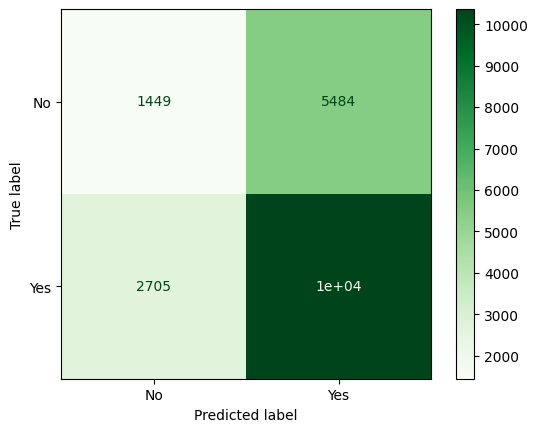

In [12]:
#  Predictions and Evaluation
# -----------------------------
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No','Yes'])
disp.plot(cmap=plt.cm.Greens)
plt.show()

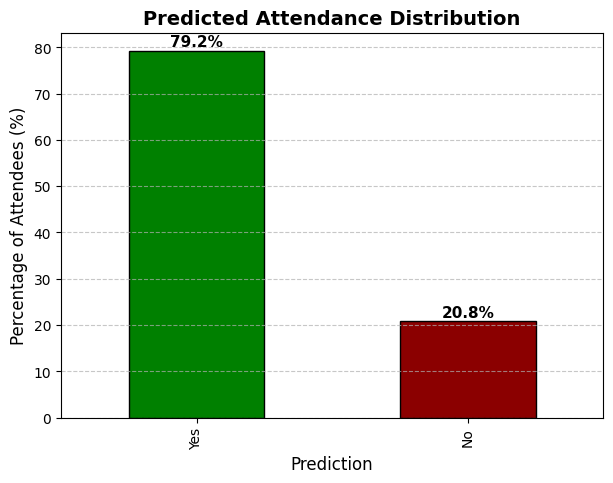

In [18]:

# Calculate percentages
percentages = result_df['Predicted_Attended'].value_counts(normalize=True) * 100

# Plot
plt.figure(figsize=(7,5))
bars = percentages.plot(kind='bar', color=['green','darkred'], edgecolor="black")

# Title & labels
plt.title("Predicted Attendance Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Prediction", fontsize=12)
plt.ylabel("Percentage of Attendees (%)", fontsize=12)

# Add percentages on top of bars
for bar in bars.patches:
    value = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, value + 1,
             f"{value:.1f}%", ha='center', fontsize=11, fontweight='bold')

# Gridlines for professionalism
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


In [19]:
# Save Results for Submission
# -----------------------------
result_df.to_csv("event_attendance_predictions.csv", index=False)
print("✅ Final predictions saved to event_attendance_predictions.csv")

✅ Final predictions saved to event_attendance_predictions.csv


In [ ]:
from google.colab import files
files.download("event_attendance_predictions.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>